# Deep Neural Networks (DNN)

## Tutorial 1- Binary Classification using DNN

This ntebook builds and trains a DNN to classify
Diabetes data

In [ ]:
# Imports
# neural network with keras tutorial
from numpy import loadtxt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# load the dataset
from google.colab import files
uploaded = files.upload()
dataset = loadtxt('pima-indians-diabetes.csv', delimiter=',')

# Visualise the dataset
dataset


Saving pima-indians-diabetes.csv to pima-indians-diabetes (1).csv


array([[  6.   , 148.   ,  72.   , ...,   0.627,  50.   ,   1.   ],
       [  1.   ,  85.   ,  66.   , ...,   0.351,  31.   ,   0.   ],
       [  8.   , 183.   ,  64.   , ...,   0.672,  32.   ,   1.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,   0.245,  30.   ,   0.   ],
       [  1.   , 126.   ,  60.   , ...,   0.349,  47.   ,   1.   ],
       [  1.   ,  93.   ,  70.   , ...,   0.315,  23.   ,   0.   ]])

### Data exploration

In [ ]:
import pandas as pd
df = pd.read_csv('pima-indians-diabetes.csv')
df.head()

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [ ]:
df.columns

Index(['6', '148', '72', '35', '0', '33.6', '0.627', '50', '1'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   6       767 non-null    int64  
 1   148     767 non-null    int64  
 2   72      767 non-null    int64  
 3   35      767 non-null    int64  
 4   0       767 non-null    int64  
 5   33.6    767 non-null    float64
 6   0.627   767 non-null    float64
 7   50      767 non-null    int64  
 8   1       767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Feature selection

In [ ]:
# split into input (X) and output (y) variables
X = dataset[:,0:8] # ":" - take all rows / "0:8" - from 0 to 8 (excludant)
y = dataset[:,8] # "Take all rows and only column 8 and store it in y"


### Build a DNN network architecture
Containing 3 Dense (fully-connected) layers,
containing, respectively, {12,8,1} nodes with the following activation function {Relu,
Relu,Sigmoid}


In [ ]:
# define the keras model
model = Sequential()
model.add(Dense(12, input_shape=(8,), activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

### Train test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


In [ ]:
# compile the keras model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

### DNN Training

In [ ]:
# fit the keras model on the dataset
history = model.fit(X_train, y_train, epochs=150, batch_size=10)


Epoch 1/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6588 - loss: 11.0688
Epoch 2/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6414 - loss: 4.5702
Epoch 3/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5726 - loss: 1.5266
Epoch 4/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5528 - loss: 1.0373
Epoch 5/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6299 - loss: 0.7881
Epoch 6/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6117 - loss: 0.7346
Epoch 7/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6198 - loss: 0.6975
Epoch 8/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6189 - loss: 0.6693
Epoch 9/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6416 - loss: 0.6555
Epoch 10/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6480 - loss: 0.6424
Epoch 11/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6323 - loss: 0.6276
Epoch 12/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

### Training visualization

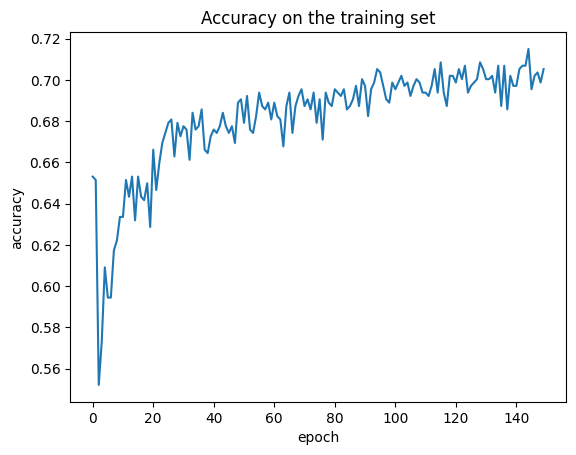

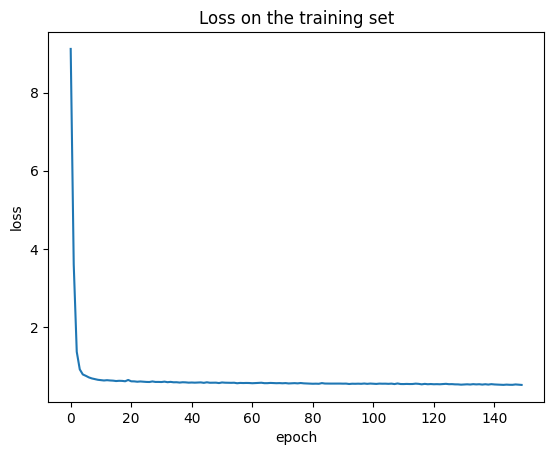

In [ ]:
# Plot the model's loss and accuracy
from matplotlib import pyplot as plt
plt.plot(history.history['accuracy'])
plt.title('Accuracy on the training set')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

plt.plot(history.history['loss'])
plt.title('Loss on the training set')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

### Metrics and Reports

In [ ]:
# evaluate the keras model
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test).ravel()
y_pred = (y_pred > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: %.2f' % (accuracy*100))
print(classification_report(y_test, y_pred))

Accuracy: 62.34
              precision    recall  f1-score   support

         0.0       0.66      0.85      0.74        99
         1.0       0.44      0.22      0.29        55

    accuracy                           0.62       154
   macro avg       0.55      0.53      0.52       154
weighted avg       0.58      0.62      0.58       154



## Exercise #1: Multi-class classification using (feedforward) DNN


### 1. Setup


In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

### 2. Data preparation


In [ ]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame = True)

In [ ]:
# Transfrom data in dataframe, then visualize the data
df_iris = iris.frame

In [ ]:
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df_iris['target'].unique()

array([0, 1, 2])

In [ ]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
# Select the features and target
X = df_iris.drop('target', axis=1)
y = df_iris['target']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
print (X_train.shape)
print (X_test.shape)
print (y_train.shape)
print (y_test.shape)

(105, 4)
(45, 4)
(105,)
(45,)


### 3. Feature and target preprocessing

#### 3.1.Label encoding
Why label encoding is applied even though the features are numerical

Although all input features in the Iris dataset (sepal length, sepal width, petal length, petal width) are already numerical and therefore do not require any encoding, the target variable (target) is categorical.

In the Iris dataset, the target values are encoded as:

0 → Setosa

1 → Versicolor

2 → Virginica

These numbers are class identifiers, not real numerical quantities. There is no meaningful order or distance between the classes. However, if these labels are used directly in a neural network, the model may incorrectly interpret them as having an ordinal relationship (e.g., class 2 > class 1 > class 0), which is not true for a classification problem.

To avoid this issue, the target labels must be one-hot encoded. One-hot encoding represents each class as a binary vector:

0 → [1, 0, 0]

1 → [0, 1, 0]

2 → [0, 0, 1]


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [83]:
# Use dense output instead of sparse output so the encoded labels are compatible with neural networks
encoder = OneHotEncoder(sparse_output=False)

In [84]:
# Reshape the training and test targets as follows:
y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.values.reshape(-1, 1)

**Why the OneHotEncoder expects a 2D array**

The `OneHotEncoder` in scikit-learn is designed to encode **categorical features**, and it assumes that the input data follows the general machine learning convention:

* **Rows represent samples**
* **Columns represent features**

For this reason, the encoder expects its input to be a **2D array with shape `(n_samples, n_features)`**, even when there is only **one feature** to encode.

In the case of the Iris dataset, the target variable (`y`) contains a single categorical feature (the class label). However, it is initially stored as a **1D array** with shape `(n_samples,)`. This shape does not explicitly indicate how many features are present.

By reshaping the target vector using:

```python
y.reshape(-1, 1)
```

we transform it into a **2D array with one column**, where:

* each row corresponds to one sample
* the single column corresponds to the categorical label feature

In [78]:
# ps: fit_transform - learn and apply the categories
y_train_encoded = encoder.fit_transform(y_train_reshaped)
y_test_encoded = encoder.transform(y_test_reshaped)

In [85]:
print(y_train_encoded[:5])

[[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [87]:
# Print the shape of the encoded target
print("Shape of encoded training target labels:", y_train_encoded.shape)
print("Shape of encoded test target labels:", y_test_encoded.shape)

Shape of encoded training target labels: (105, 3)
Shape of encoded test target labels: (45, 3)


#### 3.2.Feature normalisation

In [89]:
from sklearn.preprocessing import Normalizer

In [90]:
normalizer = Normalizer()

In [91]:
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

In [92]:
print("Normalized fearures:", X_train_norm)

Normalized fearures: [[0.77242925 0.33706004 0.51963422 0.14044168]
 [0.72366005 0.32162669 0.58582004 0.17230001]
 [0.69804799 0.338117   0.59988499 0.196326  ]
 [0.76785726 0.34902603 0.51190484 0.16287881]
 [0.69198788 0.34599394 0.58626751 0.24027357]
 [0.73446047 0.37367287 0.5411814  0.16750853]
 [0.70953708 0.28008043 0.61617694 0.1960563 ]
 [0.70631892 0.37838513 0.5675777  0.18919257]
 [0.80377277 0.55160877 0.22064351 0.0315205 ]
 [0.71486543 0.25995106 0.62202576 0.18567933]
 [0.75676497 0.35228714 0.53495455 0.13047672]
 [0.81609427 0.5336001  0.21971769 0.03138824]
 [0.80033301 0.56023311 0.20808658 0.04801998]
 [0.76693897 0.57144472 0.28572236 0.06015208]
 [0.76923077 0.30769231 0.53846154 0.15384615]
 [0.73122464 0.31338199 0.56873028 0.20892133]
 [0.776114   0.54974742 0.30721179 0.03233808]
 [0.82647451 0.4958847  0.26447184 0.03305898]
 [0.80597792 0.52151512 0.26865931 0.07901744]
 [0.73544284 0.35458851 0.55158213 0.1707278 ]
 [0.80779568 0.53853046 0.23758697 0.03

### 4. Design the deep neural network (DNN) architecture


In [99]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [97]:
# Initialize the neural network model
NN = Sequential()

In [96]:
# Calculate the feature_dim
feature_dim = X_train_norm.shape[1]
print(f"Feature dimension: {feature_dim}")

Feature dimension: 4


feature_dim represents the number of input features per sample and defines the input size of the neural network.

In [102]:
# 1st hidden layer (16 nodes, ReLU) + input dimension = feature_dim
NN.add(Dense(16, activation='relu', input_shape=(feature_dim,)))

# Dropout layer (rate = 0.2)
NN.add(Dropout(0.2))

# 2nd hidden layer (16 nodes, ReLU)
NN.add(Dense(16, activation='relu'))

# Dropout layer (rate = 0.2)
NN.add(Dropout(0.2))

# Output layer (3 units, Softmax) for 3-class classification
NN.add(Dense(3, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


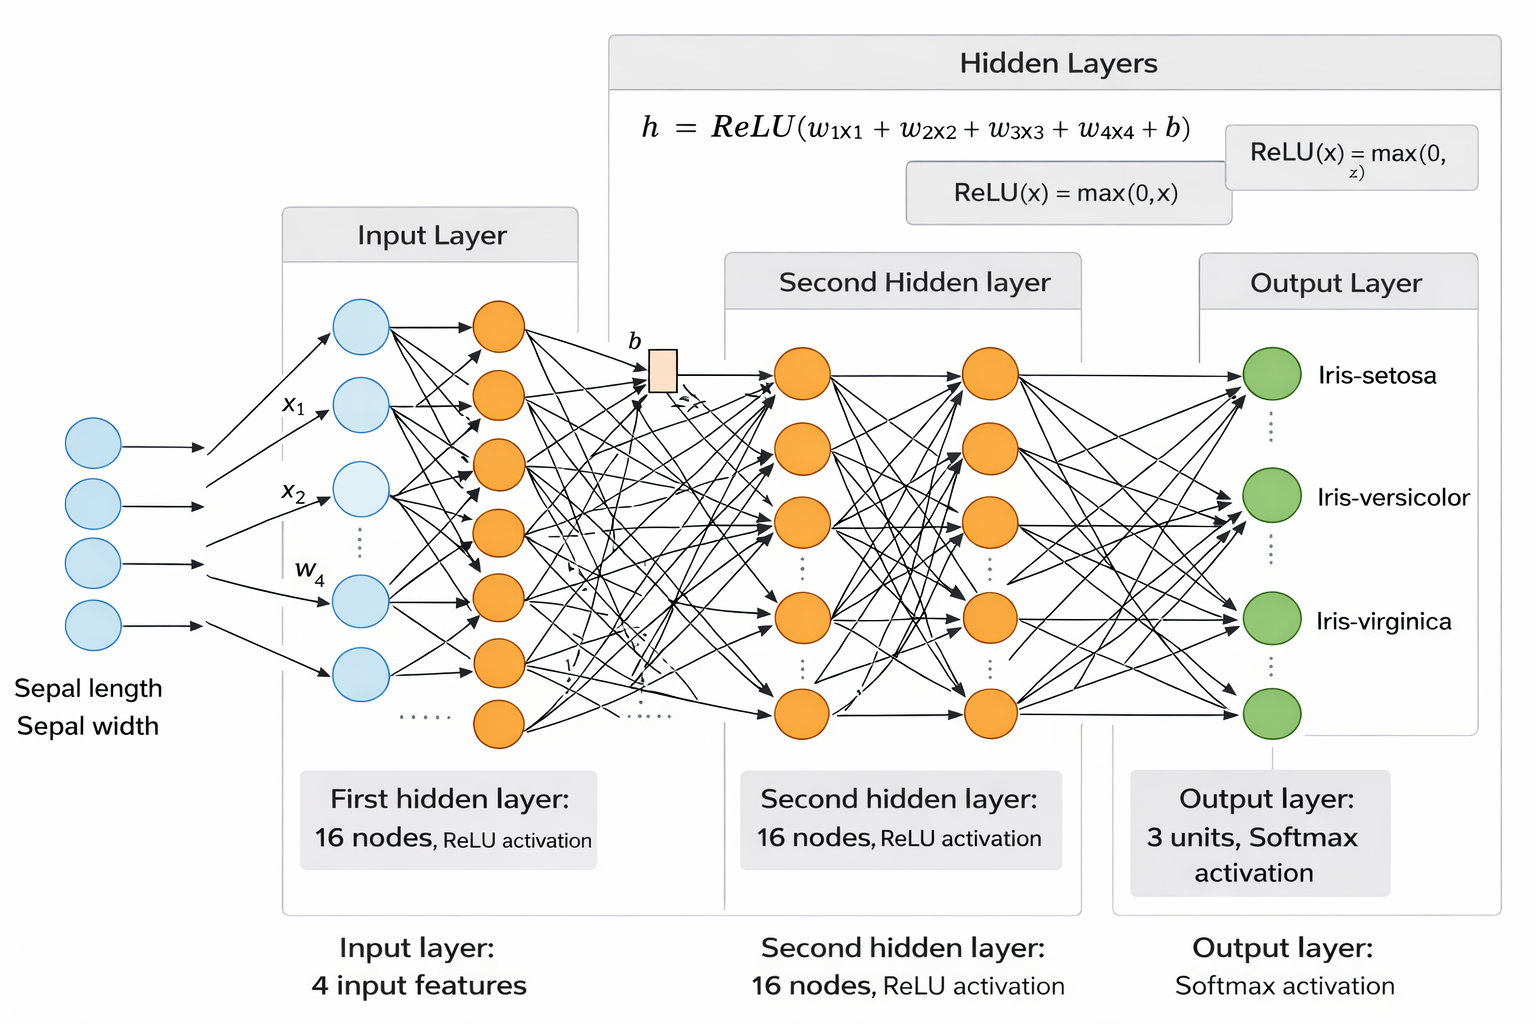

In [101]:
DNN = NN.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [104]:
# check the architecture
NN.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 790 (3.09 KB)

 Trainable params: 790 (3.09 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Training

In [106]:
history = NN.fit(
    X_train_norm,
    y_train_encoded,
    epochs=50,
    batch_size=32,
    validation_split=0.3
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 384ms/step - accuracy: 0.3167 - loss: 1.1027 - val_accuracy: 0.4062 - val_loss: 1.0864
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4242 - loss: 1.1075 - val_accuracy: 0.4062 - val_loss: 1.0862
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.3402 - loss: 1.1021 - val_accuracy: 0.4062 - val_loss: 1.0864
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.3177 - loss: 1.1040 - val_accuracy: 0.4062 - val_loss: 1.0868
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.3343 - loss: 1.0950 - val_accuracy: 0.4062 - val_loss: 1.0874
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2786 - loss: 1.1082 - val_accuracy: 0.4062 - val_loss: 1.0878
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3705 - loss: 1.0914 - val_accuracy: 0.4062 - val_loss: 1.0881
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4516 - loss: 1.0969 - val_accuracy: 0.4062 - val_loss: 1.

### 6. Testing

In [107]:
y_pred = NN.predict(X_test_norm)
y_pred

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


array([[0.27801237, 0.33740252, 0.38458514],
       [0.42311582, 0.31339845, 0.26348576],
       [0.26079926, 0.33683145, 0.40236935],
       [0.27795294, 0.3373908 , 0.38465604],
       [0.28008494, 0.33753383, 0.38238117],
       [0.42166057, 0.31364703, 0.26469243],
       [0.30208418, 0.3384528 , 0.3594631 ],
       [0.2688389 , 0.33616066, 0.3950005 ],
       [0.26852155, 0.33613473, 0.3953437 ],
       [0.292659  , 0.33819067, 0.3691503 ],
       [0.2701517 , 0.33642894, 0.3934193 ],
       [0.4232557 , 0.31338277, 0.26336148],
       [0.42758504, 0.31270635, 0.2597086 ],
       [0.42243004, 0.3135054 , 0.26406446],
       [0.42702264, 0.3127558 , 0.26022142],
       [0.28329372, 0.33774075, 0.3789655 ],
       [0.26264632, 0.33657858, 0.4007751 ],
       [0.28744757, 0.337964  , 0.37458837],
       [0.27598977, 0.33725378, 0.3867565 ],
       [0.26225835, 0.3366202 , 0.40112144],
       [0.42079845, 0.31373933, 0.26546228],
       [0.26928306, 0.33631277, 0.39440417],
       [0.

In [108]:
y_pred_labels = np.argmax(y_pred, axis=1)
y_pred_labels

array([2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 0, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0,
       0])

### 7. Metrics

In [109]:
from sklearn.metrics import classification_report, confusion_matrix

In [111]:
print(classification_report(y_test, y_pred_labels))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.00      0.00      0.00        13
           2       0.50      1.00      0.67        13

    accuracy                           0.71        45
   macro avg       0.50      0.67      0.56        45
weighted avg       0.57      0.71      0.61        45



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [112]:
print(confusion_matrix(y_test, y_pred_labels))

[[19  0  0]
 [ 0  0 13]
 [ 0  0 13]]
